##This notebook calibrates and validates four rainfall–runoff models using the CAMELS-GB dataset. The models simulate streamflow ($Q$) from precipitation ($P$) and potential evapotranspiration (PET). The notebook also includes a comprehensive performance analysis, including metric boxplots, evaluation under different hydro-climatic conditions (e.g., runoff ratio and baseflow index), analysis of model internal states, and statistical comparisons using the Wilcoxon signed-rank test.

# IMPORT LIBRARIES

In [ ]:
!pip install git+https://github.com/kratzert/RRMPG.git

  Cloning https://github.com/kratzert/RRMPG.git to /tmp/pip-req-build-fwhnagxs
  Running command git clone --filter=blob:none --quiet https://github.com/kratzert/RRMPG.git /tmp/pip-req-build-fwhnagxs
  Resolved https://github.com/kratzert/RRMPG.git to commit 7de78c25acc1c255d2acaf739d65e9ce7bbd60c3
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.3 MB/s eta 0:00:00
  Created wheel for rrmpg: filename=rrmpg-0.1.1-py3-none-any.whl size=609986 sha256=c21c44bdc457ff20efc8c71c7dd25fca2f3a8140add8ccc927c0b560364364ec
  Stored in directory: /tmp/pip-ephem-wheel-cache-t5zj06dc/wheels/7d/ec/25/408ea8f9d8a1aff931ffd2c082074611b43cc13f5e

In [ ]:
from rrmpg.models import GR4J

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

from numba import njit
import warnings
warnings.filterwarnings('ignore')

import time

##CAMELS-DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

data_dir = "/content/drive/MyDrive/CAMELS_GB/"
start_date, end_date = '1990-01-01', '2014-12-31'

print("Loading, filtering, and aligning CSV files...\n")

# 1. Fast Load & Filter
df_pcp = pd.read_csv(f"{data_dir}pcp_mm.csv", index_col=0).loc[start_date:end_date]
df_pet = pd.read_csv(f"{data_dir}pet_mm.csv", index_col=0).loc[start_date:end_date]
df_q   = pd.read_csv(f"{data_dir}q_mmd_obs.csv", index_col=0).loc[start_date:end_date]

# 2. Fast Alignment
common_stations = sorted(list(set(df_pcp.columns) & set(df_pet.columns) & set(df_q.columns)))
df_pcp = df_pcp[common_stations]
df_pet = df_pet[common_stations]
df_q   = df_q[common_stations]

print(f"✅ Data aligned. Total common stations: {len(common_stations)}")

# ============================================
# Memory-Optimized Wrapper Classes
# ============================================
class SimpleArray:
    __slots__ = ['array']  # Prevents massive RAM bloat
    def __init__(self, array):
        self.array = array
    def to_numpy(self):
        return self.array

class StationData:
    __slots__ = ['data']
    def __init__(self, data_dict):
        self.data = data_dict
    def sel(self, dynamic_features=None):
        return SimpleArray(self.data[dynamic_features])

# ============================================
# Ultra-Fast Dictionary Construction
# ============================================
print("Building ds_recent dictionary...\n")

# Convert DataFrames to 2D NumPy matrices once (orders of magnitude faster than column iteration)
pcp_arr = df_pcp.to_numpy()
pet_arr = df_pet.to_numpy()
q_arr   = df_q.to_numpy()
date_arr = pd.to_datetime(df_pcp.index).to_numpy()

# Build the dictionary using fast index slicing
ds_recent = {
    st: StationData({
        'pcp_mm': pcp_arr[:, i],
        'pet_mm': pet_arr[:, i],
        'q_mmd_obs': q_arr[:, i],
        'date': date_arr
    })
    for i, st in enumerate(common_stations)
}

print(f"✅ Dictionary built successfully!")

# ============================================
# Validation Test
# ============================================
test_station = common_stations[0]
print(f"\nTesting data access for station: {test_station}")

Q_obs = ds_recent[test_station].sel(dynamic_features="q_mmd_obs").to_numpy()
P     = ds_recent[test_station].sel(dynamic_features="pcp_mm").to_numpy()
PET   = ds_recent[test_station].sel(dynamic_features="pet_mm").to_numpy()

print(f"✅ Extraction works correctly!")
print(f"   Q_obs shape: {Q_obs.shape}")
print(f"   Q_obs - min: {np.nanmin(Q_obs):.2f}, max: {np.nanmax(Q_obs):.2f}, mean: {np.nanmean(Q_obs):.2f}")
print(f"   Q_obs Missing: {np.sum(np.isnan(Q_obs))} ({np.sum(np.isnan(Q_obs))/len(Q_obs)*100:.1f}%)")

Loading, filtering, and aligning CSV files...

✅ Data aligned. Total common stations: 671
Building ds_recent dictionary...

✅ Dictionary built successfully!

Testing data access for station: 10002
✅ Extraction works correctly!
   Q_obs shape: (9131,)
   Q_obs - min: 0.21, max: 25.04, mean: 1.37
   Q_obs Missing: 0 (0.0%)


##Metrics

In [ ]:
@njit
def NSE(obs, sim):

    n = len(obs)

    mean_obs = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i])**2
            den += (obs[i] - mean_obs)**2

    if den == 0:
        return np.nan

    return 1.0 - num / den

import numpy as np
from numba import njit


@njit
def RMSE(obs, sim):

    n = len(obs)

    mse = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


@njit
def FHV(obs, sim, top_fraction=0.02):

    mask = ~np.isnan(obs) & ~np.isnan(sim)

    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan

    n_top = int(len(obs) * top_fraction)

    if n_top == 0:
        return np.nan

    idx = np.argsort(obs)[-n_top:]

    return np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])


@njit
def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return  np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)


def KGE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2), r, alpha, beta

In [ ]:
## General Parameters of the code
b1_ratio = 0.7
max_missing_ratio = 0.1

stations = list(ds_recent.keys())

## cGRHyMoLAP

#Q(t+1) from t+1 imputs

In [ ]:
start_time = time.perf_counter()

# ============================================
# TIME DISCRETIZATION
# ============================================
dt = 0.5
nsub = int(1.0 / dt)

# ============================================
# COUPLED STORAGE + RUNOFF (S AND Q TOGETHER)
# ============================================


@njit
def cGRHyMoLAP_Model(params, Q0, Pn, En):

    MU, LAMBDA, X1, GAMMA = params

    n = len(Pn)

    Q = np.zeros(n)
    S = np.zeros(n)

    Q[0] = Q0
    S[0] = X1 / 2.0

    ratio = 4.0 / 9.0
    c = (1.0 / (4.0 * X1**4)) * ratio**4

    for t in range(n-1):

        Q_day = Q[t]
        S_day = S[t]

        for k in range(nsub):
            # choose forcing
            if k == nsub - 1:
                P_n = Pn[t + 1]
                E_n = En[t + 1]
            else:
                P_n = Pn[t]
                E_n = En[t]

            temp = S_day / X1

            Ps = P_n * (1.0 - temp**2)
            Es = E_n * (2.0 * temp - temp**2)

            perc = c * S_day**5

            # update S (first ODE)
            S_day = S_day + dt * (Ps - Es - perc)
            if S_day < 0:
                S_day = 0.0

            dQ = (
                -(MU / LAMBDA) * Q_day**(2 * MU - 1)
                + GAMMA * (c * S_day**5) * P_n
            )

            Q_day = Q_day + dt * dQ
            if Q_day < 0:
                Q_day = 0.0

        S[t + 1] = S_day
        Q[t + 1] = Q_day

    return Q, S


# ============================================
# MAIN LOOP (UNCHANGED STRUCTURE)
# ============================================

results_cGRH_semi_exp = {}

for i, station_id in enumerate(stations):

    print(f"\n=== Station {station_id} ===, Number = {i+1}")

    Q_obs = ds_recent[station_id].sel(
        dynamic_features="q_mmd_obs"
    ).to_numpy()

    P = ds_recent[station_id].sel(
        dynamic_features="pcp_mm"
    ).to_numpy()

    PET = ds_recent[station_id].sel(
        dynamic_features="pet_mm"
    ).to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)

    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    if np.sum(np.isnan(Q_obs)) / N > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    if np.isnan(Q0):
       Q0 = 0

    # ============================================
    # OPTIMIZATION
    # ============================================
    grhymolap_param_bound = [(0.5, 3.5), (1e-3, 300.0), (1e-3, 5000.0), (1e-3, 20.0)]

    initial_guesses = [
    [0.5, 1.0, 80, 0.05],
    [0.7, 2.0, 120, 0.1],
    [1.0, 5.0, 150, 0.2],
    [1.2, 8.0, 250, 0.3],
    [1.5, 10.0, 300, 0.5],
    [2.0, 15.0, 400, 0.8],
    [2.5, 20.0, 600, 1.0],
    [0.8, 3.0, 800, 0.2],
    [1.0, 6.0, 1000, 0.4],
    [3.0, 25.0, 200, 0.1],
    [1.0, 12.0, 1500, 0.6]
]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:

        res = minimize(
            lambda p: RMSE(
                Q_obs[:b1],
                cGRHyMoLAP_Model(p, Q0, Pn[:b1], En[:b1])[0]
            ),
            guess,
            method="Nelder-Mead",
            bounds = grhymolap_param_bound,
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    # ============================================
    # SIMULATION
    # ============================================

    Qsim, S = cGRHyMoLAP_Model(best_res.x, Q0, Pn, En)

    NSE_cal = NSE(Q_obs[:b1], Qsim[:b1])
    RMSE_cal = RMSE(Q_obs[:b1], Qsim[:b1])

    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    FHV_val = FHV(Q_obs[b1:], Qsim[b1:])
    FLV_val = FLV(Q_obs[b1:], Qsim[b1:])

    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_obs[b1:], Qsim[b1:])

    results_cGRH_semi_exp[station_id] = {

        "params": best_res.x,
        "Qsim": Qsim,
        "Q_obs": Q_obs,
        "S": S,

        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,

        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

    }

    print(f"   NSE cal: {NSE_cal:.4f}")
    print(f"   NSE val: {NSE_val:.4f}")

print(f"\n✅ Simulation completed for {len(results_cGRH_semi_exp)} basins.")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 ===, Number = 1
   NSE cal: 0.7389
   NSE val: 0.5976

=== Station 10003 ===, Number = 2
   NSE cal: 0.8359
   NSE val: 0.7533

=== Station 1001 ===, Number = 3

=== Station 101002 ===, Number = 4
   NSE cal: 0.7208
   NSE val: 0.7376

=== Station 101005 ===, Number = 5
   NSE cal: 0.7396
   NSE val: 0.7604

=== Station 102001 ===, Number = 6
   NSE cal: 0.7694
   NSE val: 0.7743

=== Station 106001 ===, Number = 7

=== Station 107001 ===, Number = 8

=== Station 11001 ===, Number = 9
   NSE cal: 0.7828
   NSE val: 0.6295

=== Station 11003 ===, Number = 10
   NSE cal: 0.6261
   NSE val: 0.4177

=== Station 11004 ===, Number = 11
   NSE cal: 0.7748
   NSE val: 0.6552

=== Station 12001 ===, Number = 12
   NSE cal: 0.5818
   NSE val: 0.4310

=== Station 12002 ===, Number = 13
   NSE cal: 0.6481
   NSE val: 0.5186

=== Station 12005 ===, Number = 14
   NSE cal: 0.6121
   NSE val: 0.5331

=== Station 12006 ===, Number = 15
   NSE cal: 0.4992
   NSE val: 0.3245

=== Stat

In [ ]:
# ============================================
# SAVE RESULTS TO CSV
# ============================================

rows = []

for station_id, res in results_cGRH_semi_exp.items():

    MU, LAMBDA, X1, GAMMA = res["params"]

    rows.append({
        "station_id": station_id,

        "MU": MU,
        "LAMBDA": LAMBDA,
        "X1": X1,
        "GAMMA": GAMMA,

        "NSE_cal": res["NSE_cal"],
        "NSE_val": res["NSE_val"],

        "RMSE_cal": res["RMSE_cal"],
        "RMSE_val": res["RMSE_val"],

        "FHV_val": res["FHV_val"],
        "FLV_val": res["FLV_val"],
        "KGE_val": res["KGE_val"],
    })

df_results = pd.DataFrame(rows)

csv_name = "cGRHyMoLAP_semi_exp_results.csv"
df_results.to_csv(csv_name, index=False)

print(f"✅ Results saved to {csv_name}")

# ============================================
# DOWNLOAD TO LOCAL COMPUTER
# ============================================

#files.download(csv_name)

✅ Results saved to cGRHyMoLAP_semi_exp_results.csv


In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.816, 5th percentile: 0.6339, 95th percentile: 0.9196
MEAN NSE_CAL: 0.8027562153567339
MIN NSE_CAL: 0.0729768934549112
MAX NSE_CAL: 0.9544865469433179

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.781, 5th percentile: 0.1444, 95th percentile: 2.7130
MEAN RMSE_CAL: 1.0622916588005762
MIN RMSE_CAL: 0.047190860584618306
MAX RMSE_CAL: 10.223686620144784


================= VALIDATION =================

NSE Validation -> Median: 0.786, 5th percentile: 0.5338, 95th percentile: 0.9100
MEAN NSE_VAL: 0.7600383432354919
MIN NSE_VAL: -1.646626692073669
MAX NSE_VAL: 0.9561095821977753

--- RMSE Validation ---
RMSE Validation -> Median: 0.941, 5th percentile: 0.1630, 95th percentile: 3.0530
MEAN RMSE_VAL: 1.1945957890033891
MIN RMSE_VAL: 0.03941320076171775
MAX RMSE_VAL: 9.997008130116887


GRHyMoLAP

Q(t+1) from t+1 inputs

In [ ]:
start_time = time.perf_counter()

# ============================================
# NUMBA FUNCTIONS
# ============================================

@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    Perc = np.zeros(n)

    S[0] = X1 / 2.0
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))

    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2

        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))

        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))

        S[i] = S[i-1] + Ps - Es

        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))

        S[i] -= Perc[i]

    return Perc, S


@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)

    Q = np.zeros(N)
    Q[0] = Q0

    Perc, S = Percolation(Pn, En, X1)

    for t in range(N-1):
        Q[t+1] = max(
            0.0,
            Q[t]
            - (MU / LAMBDA) * (Q[t])**(2*MU - 1)
            + GAMMA * Perc[t+1] * Pn[t+1]
        )

    return Q

# ============================================
# SETTINGS
# ============================================

results_GRH_semi_exp = {}

# ============================================
# MAIN LOOP
# ============================================

for i, station_id in enumerate(stations):

    print(f"\n=== Station {station_id} ===, Number = {i+1}")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mmd_obs").to_numpy()
    P     = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    PET   = ds_recent[station_id].sel(dynamic_features="pet_mm").to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    if np.isnan(Q0):
       Q0 = 0

    # ============================================
    # OPTIMIZATION
    # ============================================
    grhymolap_param_bound = [(0.5, 3.5), (1e-3, 300.0), (1e-3, 5000.0), (1e-3, 20.0)]

    initial_guesses = [
    [0.5, 1.0, 80, 0.05],
    [0.7, 2.0, 120, 0.1],
    [1.0, 5.0, 150, 0.2],
    [1.2, 8.0, 250, 0.3],
    [1.5, 10.0, 300, 0.5],
    [2.0, 15.0, 400, 0.8],
    [2.5, 20.0, 600, 1.0],
    [0.8, 3.0, 800, 0.2],
    [1.0, 6.0, 1000, 0.4],
    [3.0, 25.0, 200, 0.1],
    [1.0, 12.0, 1500, 0.6]
]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:
        res = minimize(
            lambda p: RMSE(
                Q_obs[:b1],
                GRHyMoLAP_Model(p, Q0, Pn[:b1], En[:b1])
            ),
            guess,
            method="Nelder-Mead",
            bounds = grhymolap_param_bound,
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x

    # ============================================
    # SIMULATION
    # ============================================

    Qsim = GRHyMoLAP_Model(best_res.x, Q0, Pn, En)

    NSE_cal = NSE(Q_obs[:b1], Qsim[:b1])
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_cal = RMSE(Q_obs[:b1], Qsim[:b1])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    FHV_val = FHV(Q_obs[b1:], Qsim[b1:])
    FLV_val = FLV(Q_obs[b1:], Qsim[b1:])
    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_obs[b1:], Qsim[b1:])

    S = Percolation(Pn, En, X1)[1]

    # ============================================
    # STORE RESULTS (FULL PRESERVED)
    # ============================================

    results_GRH_semi_exp[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "Qsim": Qsim,
        "S": S,
        "Q_obs": Q_obs,

        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,

        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

    }

    print(f" NSE cal: {NSE_cal:.4f}")
    print(f" NSE val: {NSE_val:.4f}")

print(f"\n✅ Simulation completed for {len(results_GRH_semi_exp)} valid basins.")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 ===, Number = 1
 NSE cal: 0.6854
 NSE val: 0.5358

=== Station 10003 ===, Number = 2
 NSE cal: 0.8382
 NSE val: 0.7503

=== Station 1001 ===, Number = 3
⚠️ Too many missing values (23.4%)

=== Station 101002 ===, Number = 4
 NSE cal: 0.7321
 NSE val: 0.7423

=== Station 101005 ===, Number = 5
 NSE cal: 0.7511
 NSE val: 0.7790

=== Station 102001 ===, Number = 6
 NSE cal: 0.7238
 NSE val: 0.7415

=== Station 106001 ===, Number = 7
⚠️ Too many missing values (28.0%)

=== Station 107001 ===, Number = 8
⚠️ Too many missing values (38.4%)

=== Station 11001 ===, Number = 9
 NSE cal: 0.7615
 NSE val: 0.5962

=== Station 11003 ===, Number = 10
 NSE cal: 0.6508
 NSE val: 0.4247

=== Station 11004 ===, Number = 11
 NSE cal: 0.8031
 NSE val: 0.6859

=== Station 12001 ===, Number = 12
 NSE cal: 0.5688
 NSE val: 0.4072

=== Station 12002 ===, Number = 13
 NSE cal: 0.6314
 NSE val: 0.4927

=== Station 12005 ===, Number = 14
 NSE cal: 0.6272
 NSE val: 0.5267

=== Station 12006 ===

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GRH_semi_exp.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GRH_semi_exp.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GRH_semi_exp.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GRH_semi_exp.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.787, 5th percentile: 0.6281, 95th percentile: 0.9092
MEAN NSE_CAL: 0.7814399107592024
MIN NSE_CAL: 0.05885001050479077
MAX NSE_CAL: 0.9506259493912581

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.841, 5th percentile: 0.1503, 95th percentile: 2.8037
MEAN RMSE_CAL: 1.1133037143574298
MIN RMSE_CAL: 0.048459348307743545
MAX RMSE_CAL: 10.242094881778334


================= VALIDATION =================

NSE Validation -> Median: 0.758, 5th percentile: 0.5169, 95th percentile: 0.8908
MEAN NSE_VAL: 0.7346496349288566
MIN NSE_VAL: -1.7026746467237177
MAX NSE_VAL: 0.9507097595818322

--- RMSE Validation ---
RMSE Validation -> Median: 1.010, 5th percentile: 0.1719, 95th percentile: 3.0532
MEAN RMSE_VAL: 1.2528198740823604
MIN RMSE_VAL: 0.03968719486955541
MAX RMSE_VAL: 10.076058049280638


#GR4J

In [ ]:
start_time = time.perf_counter()

# ============================================
# General infos
# ============================================

results_GR4J = {}

# ============================================
# GR4J objective function (minimize RMSE)
# ============================================
def objective_gr4j(x, Q, P, ET):
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), x))
    model.set_params(params)
    try:
        Qsim = model.simulate(P, ET).flatten()
        rmse = RMSE(Q, Qsim)
        return rmse if np.isfinite(rmse) else 1e6
    except Exception:
        return 1e6


# ============================================
# GR4J bounds
# ============================================
bounds = [
    (1, 3500),   # x1
    (-15, 15),   # x2
    (1, 1200),   # x3
    (0.5, 5)     # x4
]

# ============================================
# Main loop over basins
# ============================================
for i, station_id in enumerate(stations, start=1):

    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mmd_obs").to_numpy()
    P = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    ET = ds_recent[station_id].sel(dynamic_features="pet_mm").to_numpy()

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station ignored (no valid data)")
        continue

    missing_ratio = np.isnan(Q_obs).sum() / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    # ============================================
    # Split calibration / validation
    # ============================================
    b1 = int(N * b1_ratio)

    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # ============================================
    # Multi-start calibration
    # ============================================
    best_fun = np.inf
    best_x = None
    np.random.seed(42)

    for _ in range(20):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]

        res = minimize(
            objective_gr4j,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 3000}
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        print("⚠️ Calibration failed")
        continue

    # ============================================
    # Final simulation
    # ============================================
    model = GR4J()
    params = dict(zip(model.get_parameter_names(), best_x))
    model.set_params(params)

    Qsim_cal = model.simulate(P_cal, ET_cal).flatten()
    Qsim_val = model.simulate(P_val, ET_val).flatten()

    # ============================================
    # Metrics
    # ============================================
    nse_cal = NSE(Q_cal, Qsim_cal)
    rmse_cal = RMSE(Q_cal, Qsim_cal)

    nse_val = NSE(Q_val, Qsim_val)
    rmse_val = RMSE(Q_val, Qsim_val)

    FHV_val = FHV(Q_val, Qsim_val)
    FLV_val = FLV(Q_val, Qsim_val)
    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_val, Qsim_val)

    # ============================================
    # Store results
    # ============================================
    results_GR4J[station_id] = {
        "NSE_cal": nse_cal,
        "RMSE_cal": rmse_cal,
        "NSE_val": nse_val,
        "RMSE_val": rmse_val,
        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

        "Qsim": Qsim_val,

        **params
    }

    # ============================================
    # Display
    # ============================================
    print(f"NSE calibration   : {nse_cal:.3f}")
    print(f"NSE validation    : {nse_val:.3f}")

print(f"\n✅ Finished : {len(results_GR4J)} calibrated basins")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 (1/671) ===
NSE calibration   : 0.839
NSE validation    : 0.685

=== Station 10003 (2/671) ===
NSE calibration   : 0.876
NSE validation    : 0.695

=== Station 1001 (3/671) ===
⚠️ Too many missing values (23.4%)

=== Station 101002 (4/671) ===
NSE calibration   : 0.720
NSE validation    : 0.656

=== Station 101005 (5/671) ===
NSE calibration   : 0.736
NSE validation    : 0.808

=== Station 102001 (6/671) ===
NSE calibration   : 0.791
NSE validation    : 0.781

=== Station 106001 (7/671) ===
⚠️ Too many missing values (28.0%)

=== Station 107001 (8/671) ===
⚠️ Too many missing values (38.4%)

=== Station 11001 (9/671) ===
NSE calibration   : 0.845
NSE validation    : 0.613

=== Station 11003 (10/671) ===
NSE calibration   : 0.700
NSE validation    : 0.401

=== Station 11004 (11/671) ===
NSE calibration   : 0.839
NSE validation    : 0.585

=== Station 12001 (12/671) ===
NSE calibration   : 0.583
NSE validation    : 0.411

=== Station 12002 (13/671) ===
NSE calibration 

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_GR4J.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_GR4J.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_GR4J.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_GR4J.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.814, 5th percentile: 0.5673, 95th percentile: 0.9007
MEAN NSE_CAL: 0.7826899265047589
MIN NSE_CAL: -0.5286319282541476
MAX NSE_CAL: 0.9550577706677827

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.757, 5th percentile: 0.1865, 95th percentile: 2.7695
MEAN RMSE_CAL: 1.0628525730765996
MIN RMSE_CAL: 0.0805996707558844
MAX RMSE_CAL: 10.52069210892935


================= VALIDATION =================

NSE Validation -> Median: 0.759, 5th percentile: 0.1968, 95th percentile: 0.8877
MEAN NSE_VAL: 0.665496505753149
MIN NSE_VAL: -3.6695473000443
MAX NSE_VAL: 0.9553012114514174

--- RMSE Validation ---
RMSE Validation -> Median: 0.931, 5th percentile: 0.2520, 95th percentile: 3.0295
MEAN RMSE_VAL: 1.2335054870412532
MIN RMSE_VAL: 0.1305648855778599
MAX RMSE_VAL: 10.089213602640902


##HBV

In [ ]:
start_time = time.perf_counter()

# ============================================
# 1️⃣ General setting
# ============================================

results_HBV = {}

# ============================================
# 3️⃣ HBV
# ============================================
@njit
def hbv_numba(P, ET, params):
    FC, BETA, LP, K0, K1, K2, UZL, PERC = params

    SM = 0.5 * FC
    UZ = 0.0
    LZ = 0.0

    n = len(P)
    Qsim = np.zeros(n)

    for t in range(n):
        p = P[t]
        et = ET[t]

        # Soil moisture
        soil_ratio = SM / FC
        recharge = p * soil_ratio**BETA
        SM += p - recharge
        if SM > FC:
            recharge += SM - FC
            SM = FC
        evap = min(et * min(SM / (LP * FC), 1.0), SM)
        SM -= evap

        # Upper reservoir
        UZ += recharge
        perc = min(PERC, UZ)
        UZ -= perc
        LZ += perc

        # Quick flow
        Q0 = K0 * (UZ - UZL) if UZ > UZL else 0.0
        if Q0 > 0:
            UZ -= Q0

        # Interflow
        Q1 = K1 * UZ
        UZ -= Q1

        # Baseflow
        Q2 = K2 * LZ
        LZ -= Q2

        # Total discharge
        Qsim[t] = max(0.0, Q0 + Q1 + Q2)

    return Qsim

# ============================================
# 4️⃣ Fonction objective
# ============================================
def objective_hbv(x, Q, P, ET):
    Qsim = hbv_numba(P, ET, x)
    nse = NSE(Q, Qsim)
    return 1 - nse if np.isfinite(nse) else 1e6

# ============================================
# 5️⃣ Boucle sur stations
# ============================================
bounds = [
    (50,1000), (1,6), (0.3,1), (0,0.5), (0,0.3),
    (0,0.1), (0,100), (0,5)
]

for i, station_id in enumerate(stations, start=1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mmd_obs").to_numpy()
    P     = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    ET   = ds_recent[station_id].sel(dynamic_features="pet_mm").to_numpy()

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        continue

    # Calibration / validation
    b1 = int(N * b1_ratio)
    Q_cal, Q_val = Q_obs[:b1], Q_obs[b1:]
    P_cal, P_val = P[:b1], P[b1:]
    ET_cal, ET_val = ET[:b1], ET[b1:]

    # Multi-start calibration
    best_fun = np.inf
    best_x = None
    np.random.seed(42)
    for _ in range(20):
        x0 = [np.random.uniform(b[0], b[1]) for b in bounds]
        res = minimize(
            objective_hbv,
            x0,
            args=(Q_cal, P_cal, ET_cal),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter":3000}
        )
        if res.fun < best_fun:
            best_fun = res.fun
            best_x = res.x

    if best_x is None:
        continue

    Qsim_cal = hbv_numba(P_cal, ET_cal, best_x)
    Qsim_val = hbv_numba(P_val, ET_val, best_x)

    # ============================================
    # Metrics
    # ============================================
    nse_cal = NSE(Q_cal, Qsim_cal)
    rmse_cal = RMSE(Q_cal, Qsim_cal)

    nse_val = NSE(Q_val, Qsim_val)
    rmse_val = RMSE(Q_val, Qsim_val)

    FHV_val = FHV(Q_val, Qsim_val)
    FLV_val = FLV(Q_val, Qsim_val)
    KGE_val, KGE_1, KGE_2, KGE_3  = KGE(Q_val, Qsim_val)

    # ============================================
    # Store results
    # ============================================
    results_HBV[station_id] = {
        "NSE_cal": nse_cal,
        "RMSE_cal": rmse_cal,
        "NSE_val": nse_val,
        "RMSE_val": rmse_val,
        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val,
        "KGE_1": KGE_1,
        "KGE_2": KGE_2,
        "KGE_3": KGE_3,

        "Qsim": Qsim_val,

        **params
    }

    # ============================================
    # Display
    # ============================================
    print(f"NSE calibration   : {nse_cal:.3f}")
    print(f"NSE validation    : {nse_val:.3f}")

print(f"\n✅ Finished : {len(results_HBV)} calibrated basins")

end_time = time.perf_counter()

total_time = end_time - start_time

print(f"Total time: {total_time:.2f} s")
print(f"Total time: {total_time/60:.2f} min")
print(f"Total time: {total_time/3600:.2f} h")


=== Station 10002 (1/671) ===
NSE calibration   : 0.718
NSE validation    : 0.577

=== Station 10003 (2/671) ===
NSE calibration   : 0.849
NSE validation    : 0.751

=== Station 1001 (3/671) ===

=== Station 101002 (4/671) ===
NSE calibration   : 0.757
NSE validation    : 0.680

=== Station 101005 (5/671) ===
NSE calibration   : 0.761
NSE validation    : 0.783

=== Station 102001 (6/671) ===
NSE calibration   : 0.719
NSE validation    : 0.737

=== Station 106001 (7/671) ===

=== Station 107001 (8/671) ===

=== Station 11001 (9/671) ===
NSE calibration   : 0.802
NSE validation    : 0.600

=== Station 11003 (10/671) ===
NSE calibration   : 0.723
NSE validation    : 0.443

=== Station 11004 (11/671) ===
NSE calibration   : 0.836
NSE validation    : 0.681

=== Station 12001 (12/671) ===
NSE calibration   : 0.604
NSE validation    : 0.424

=== Station 12002 (13/671) ===
NSE calibration   : 0.671
NSE validation    : 0.517

=== Station 12005 (14/671) ===
NSE calibration   : 0.660
NSE validat

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_HBV.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_HBV.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['FLV_val'] for res in results_HBV.values() if not np.isnan(res['FLV_val'])]
rmse_val = [res['RMSE_val'] for res in results_HBV.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.800, 5th percentile: 0.6036, 95th percentile: 0.9002
MEAN NSE_CAL: 0.7725328054385868
MIN NSE_CAL: -3.447807221879847
MAX NSE_CAL: 0.9325791809293669

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.817, 5th percentile: 0.1733, 95th percentile: 2.8321
MEAN RMSE_CAL: 1.1114939896616236
MIN RMSE_CAL: 0.04552008312855641
MAX RMSE_CAL: 11.270362337036808


================= VALIDATION =================

NSE Validation -> Median: 0.151, 5th percentile: -0.4501, 95th percentile: 1.0540
MEAN NSE_VAL: 216344.26371047337
MIN NSE_VAL: -0.7867641772460133
MAX NSE_VAL: 74121232.87764007

--- RMSE Validation ---
RMSE Validation -> Median: 1.010, 5th percentile: 0.2272, 95th percentile: 3.0277
MEAN RMSE_VAL: 1.2825234862607102
MIN RMSE_VAL: 0.08054866929574574
MAX RMSE_VAL: 10.43881874381692


#Distribution

In [ ]:
hydro = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_hydrologic_attributes.csv', sep=',')

climate = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_climatic_attributes.csv', sep=',')

lc = pd.read_csv('/content/drive/MyDrive/CAMELS_GB/CAMELS_GB_landcover_attributes.csv', sep=',')

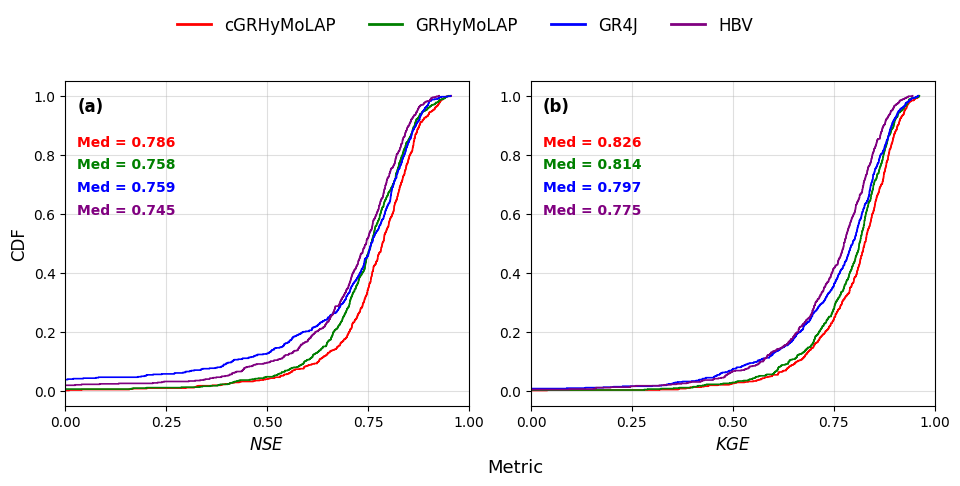

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models = {
    "cGRHyMoLAP": results_cGRH_semi_exp,
    "GRHyMoLAP": results_GRH_semi_exp,
    "GR4J": results_GR4J,
    "HBV": results_HBV
}

colors = ["red", "green", "blue", "purple"]

metrics = [
    ("NSE_val", "$NSE$", (0.0, 1.0)),
    ("KGE_val", "$KGE$", (0.0, 1.0))
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

panel_labels = ["(a)", "(b)"]

for ax, (metric_key, metric_name, xlim), panel in zip(
        axes, metrics, panel_labels):

    stats_text = []

    for (name, res), color in zip(models.items(), colors):

        vals = np.array([
            res[s][metric_key]
            for s in res
            if metric_key in res[s]
            and not np.isnan(res[s][metric_key])
        ])

        if len(vals) == 0:
            continue

        # =====================================================
        # CDF
        # =====================================================

        vals_sorted = np.sort(vals)
        cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)

        x = np.concatenate(([vals_sorted[0]], vals_sorted))
        y = np.concatenate(([0], cdf))

        ax.step(
            x,
            y,
            where="post",
            linewidth=1.2,
            color=color
        )

        stat_val = np.median(vals)
        stats_text.append((color, f"Med = {stat_val:.3f}"))

    # =====================================================
    # panel label
    # =====================================================

    ax.text(
        0.03, 0.95, panel,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top"
    )

    # =====================================================
    # stats
    # =====================================================

    for k, (color, txt) in enumerate(stats_text):
        ax.text(
            0.03,
            0.80 - 0.07 * k,
            txt,
            color=color,
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            ha="left"
        )

    # =====================================================
    # axis formatting
    # =====================================================

    ax.set_xlabel(metric_name, fontsize=12)
    ax.set_xlim(*xlim)
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, alpha=0.4)

# =====================================================
# shared ylabel
# =====================================================

axes[0].set_ylabel("CDF", fontsize=12)

# =====================================================
# GLOBAL xlabel (IMPORTANT PART)
# =====================================================

fig.supxlabel("Metric", fontsize=13, x=0.55, y=0.1)

# =====================================================
# legend
# =====================================================

handles = [
    Line2D([0], [0], color="red", lw=2, label="cGRHyMoLAP"),
    Line2D([0], [0], color="green", lw=2, label="GRHyMoLAP"),
    Line2D([0], [0], color="blue", lw=2, label="GR4J"),
    Line2D([0], [0], color="purple", lw=2, label="HBV")
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12
)

plt.tight_layout(rect=[0.03, 0.05, 1, 0.92])

plt.savefig(
    "global_perf.jpeg",
    dpi=700,
    bbox_inches="tight"
)
#files.download("global_perf.jpeg")

plt.show()

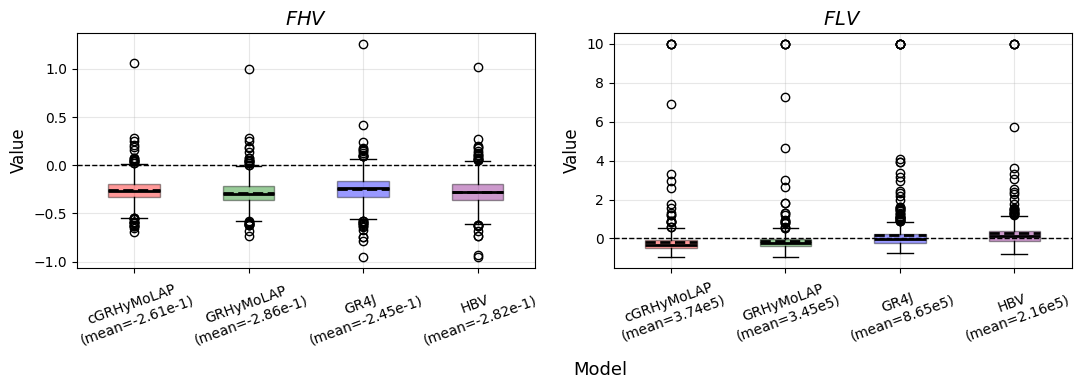

In [ ]:
models = {
    "cGRHyMoLAP": results_cGRH_semi_exp,
    "GRHyMoLAP": results_GRH_semi_exp,
    "GR4J": results_GR4J,
    "HBV": results_HBV
}

colors = ["red", "green", "blue", "purple"]

metrics = ["FHV_val", "FLV_val"]
titles = [r"$FHV$", r"$FLV$"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, title in zip(axes, metrics, titles):

    data = []
    xticklabels = []

    for name, res in models.items():

        vals = np.array([
            res[s][metric]
            for s in res
            if metric in res[s]
            and not np.isnan(res[s][metric])
        ])

        # =====================================================
        # TRUE MEAN (before clipping)
        # =====================================================
        mean_val = np.mean(vals)

        # Scientific notation without "+" or leading zeros
        mean_str = f"{mean_val:.2e}"
        base, exp = mean_str.split("e")
        exp = str(int(exp))
        mean_str = f"{base}e{exp}"

        # =====================================================
        # CLIP ONLY FOR DISPLAY
        # =====================================================
        plot_vals = vals.copy()

        if metric == "FLV_val":
            plot_vals = np.clip(plot_vals, -10, 10)

        data.append(plot_vals)

        xticklabels.append(
            f"{name}\n(mean={mean_str})"
        )

    # =====================================================
    # BOXPLOT
    # =====================================================
    bp = ax.boxplot(
        data,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        showfliers=True
    )

    # =====================================================
    # COLORS
    # =====================================================
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    for mean in bp["means"]:
        mean.set_color("black")
        mean.set_linewidth(2)

    # =====================================================
    # Reference line
    # =====================================================
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    # =====================================================
    # Labels
    # =====================================================
    ax.set_title(
        title,
        fontsize=14
    )

    ax.set_xticks(
        np.arange(1, len(models) + 1)
    )

    ax.set_xticklabels(
        xticklabels,
        rotation=20,
        fontsize=10
    )

    ax.set_ylabel(
        "Value",
        fontsize=12
    )

    ax.grid(
        True,
        alpha=0.3
    )

fig.supxlabel(
    "Model",
    fontsize=13,
    x=0.55,
    y=0.04
)

plt.tight_layout()

plt.savefig(
    "fhv_flv.jpeg",
    dpi=700,
    bbox_inches="tight"
)
#files.download("fhv_flv.jpeg")
plt.show()

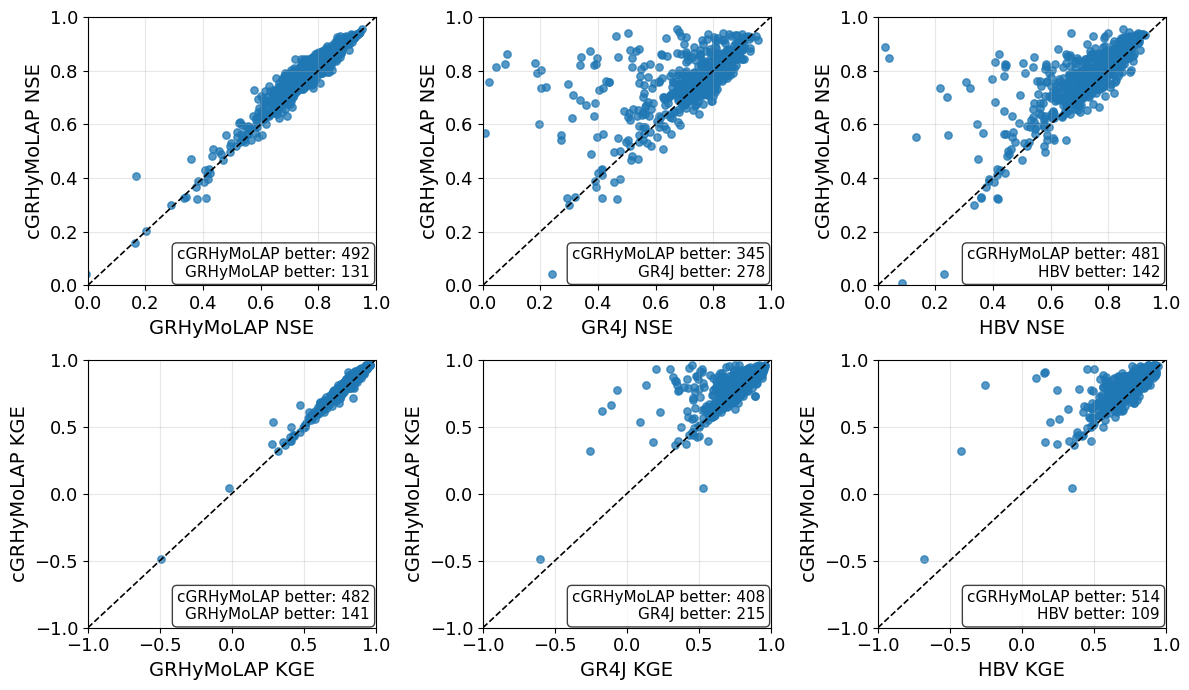

In [ ]:
metrics = [
    ("NSE_val", "NSE", (0, 1), (0, 1)),
    ("KGE_val", "KGE", (-1, 1), (-1, 1))
]

baselines = {
    "GRHyMoLAP": results_GRH_semi_exp,
    "GR4J": results_GR4J,
    "HBV": results_HBV
}

target = results_cGRH_semi_exp

fig, axes = plt.subplots(
    len(metrics),
    len(baselines),
    figsize=(12, 7)
)

def count(a, b, metric):
    better = np.sum(a > b)
    worse  = np.sum(a < b)
    return better, worse


for row, (metric, metric_label, xlim, ylim) in enumerate(metrics):

    common_catchments = (
        set(target.keys())
        & set(results_GR4J.keys())
        & set(results_GRH_semi_exp.keys())
        & set(results_HBV.keys())
    )

    for col, (name, base_model) in enumerate(baselines.items()):

        base_vals = []
        cgrh_vals = []

        for catch in common_catchments:

            if metric not in base_model[catch]:
                continue
            if metric not in target[catch]:
                continue

            b = base_model[catch][metric]
            c = target[catch][metric]

            if np.isnan(b) or np.isnan(c):
                continue

            base_vals.append(b)
            cgrh_vals.append(c)

        base_vals = np.array(base_vals)
        cgrh_vals = np.array(cgrh_vals)

        better, worse = count(cgrh_vals, base_vals, metric)

        ax = axes[row, col]

        # =====================================================
        # PLOT
        # =====================================================

        ax.scatter(
            base_vals,
            cgrh_vals,
            alpha=0.75,
            s=28   # increased
        )

        ax.plot(
            [xlim[0], xlim[1]],
            [xlim[0], xlim[1]],
            'k--',
            lw=1.2
        )

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # =====================================================
        # TEXT SIZE INCREASED
        # =====================================================

        ax.set_xlabel(f"{name} {metric_label}", fontsize=14)
        ax.set_ylabel(f"cGRHyMoLAP {metric_label}", fontsize=14)

        ax.tick_params(axis='both', labelsize=13)

        # =====================================================
        # LEGEND bottom-right
        # =====================================================

        ax.text(
            0.98,
            0.02,
            f"cGRHyMoLAP better: {better}\n"
            f"{name} better: {worse}",
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
        )

        ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "cgrh_vs_all_models.jpeg",
    dpi=700,
    bbox_inches="tight"
)
#files.download("cgrh_vs_all_models.jpeg")
plt.show()

##Internal plots

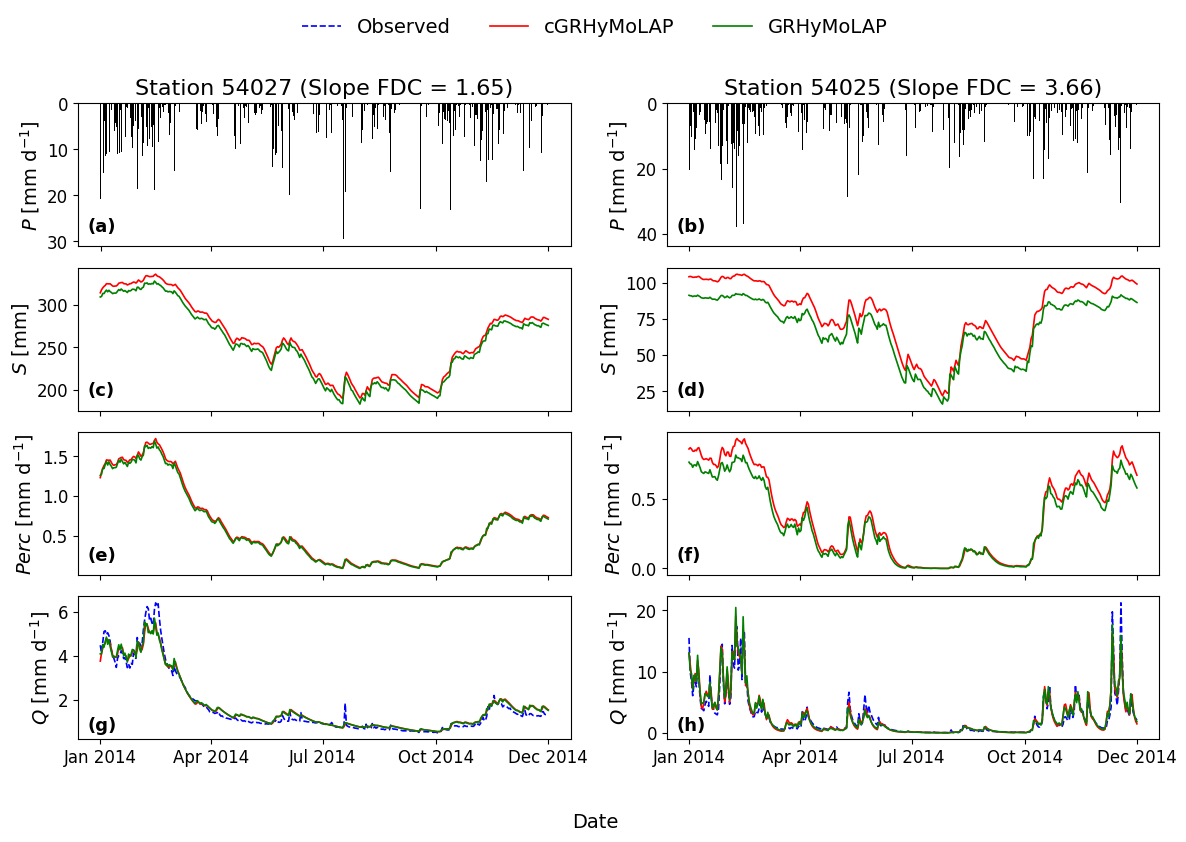

In [ ]:
# ==========================================================
# FONT SIZES
# ==========================================================

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 14
PANEL_SIZE = 13

# ==========================================================
# SETTINGS
# ==========================================================

indices = [460, 459]

dates = pd.date_range(
    start="2014-01-01",
    periods=365,
    freq="D"
)

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 8)
)

panel_labels = [
    "(a)", "(b)",
    "(c)", "(d)",
    "(e)", "(f)",
    "(g)", "(h)"
]

# Couleurs identiques pour S, Perc et Q

color_cgrh = "red"
color_grh = "green"
color_obs = "blue"

# ==========================================================
# Ligne 1 : Effective Precipitation
# ==========================================================

for j, idx in enumerate(indices):

    ax = axes[0, j]

    station_id = stations[idx]

    P = ds_recent[station_id].sel(
        dynamic_features="pcp_mm"
    ).to_numpy()

    # ------------------------------------------------------
    # SLOPE FDC
    # ------------------------------------------------------
    fdc_val = hydro.loc[
        hydro["gauge_id"].astype(str) == str(station_id),
        "slope_fdc"
    ].values[0]

    ax.bar(
        dates,
        P[-365:],
        color="black",
        width=0.7
    )

    # style hydrograph classique
    ax.invert_yaxis()

    ax.set_ylim(
        np.max(P[-365:]) * 1.05,
        0
    )

    ax.text(
        0.02,
        0.2,
        panel_labels[j],
        transform=ax.transAxes,
        fontsize=PANEL_SIZE,
        fontweight="bold",
        va="top"
    )

    ax.set_title(
        f"Station {station_id} (Slope FDC = {fdc_val:.2f})",
        fontsize=TITLE_SIZE
    )

    ax.set_ylabel(
        r"$P$ [mm d$^{-1}$]",
        fontsize=LABEL_SIZE
    )

    ax.yaxis.set_label_position("left")
    ax.yaxis.tick_left()

    ax.set_xticks(pd.to_datetime([
        "2014-01-01",
        "2014-04-01",
        "2014-07-01",
        "2014-10-01",
        "2014-12-31"
    ]))

    ax.set_xticklabels([])

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.grid(False)

# ==========================================================
# Ligne 2 : S
# ==========================================================

for j, idx in enumerate(indices):

    ax = axes[1, j]

    station_id = stations[idx]

    S_c = results_cGRH_semi_exp[station_id]["S"]
    S_grh = results_GRH_semi_exp[station_id]["S"]

    ax.plot(
        dates,
        S_c[-365:],
        label="cGRHyMoLAP",
        color=color_cgrh,
        linewidth=1.2
    )

    ax.plot(
        dates,
        S_grh[-365:],
        label="GRHyMoLAP",
        color=color_grh,
        linewidth=1.2
    )

    ax.text(
        0.02,
        0.2,
        panel_labels[j + 2],
        transform=ax.transAxes,
        fontsize=PANEL_SIZE,
        fontweight="bold",
        va="top"
    )

    ax.set_ylabel(
        r"$S$ [mm]",
        fontsize=LABEL_SIZE
    )

    ax.set_xticks(pd.to_datetime([
        "2014-01-01",
        "2014-04-01",
        "2014-07-01",
        "2014-10-01",
        "2014-12-31"
    ]))

    ax.set_xticklabels([])

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

# ==========================================================
# Ligne 3 : Perc
# ==========================================================

for j, idx in enumerate(indices):

    ax = axes[2, j]

    station_id = stations[idx]

    S_c = results_cGRH_semi_exp[station_id]["S"][-365:]
    S_grh = results_GRH_semi_exp[station_id]["S"][-365:]

    X1_c = results_cGRH_semi_exp[station_id]["params"][2]
    X1_grh = results_GRH_semi_exp[station_id]["params"][2]

    Perc_c = (
        (1 / (4 * X1_c**4))
        * (4 / 9)**4
        * S_c**5
    )

    Perc_grh = (
        (1 / (4 * X1_grh**4))
        * (4 / 9)**4
        * S_grh**5
    )

    ax.plot(
        dates,
        Perc_c,
        color=color_cgrh,
        linewidth=1.2,
        label="cGRHyMoLAP"
    )

    ax.plot(
        dates,
        Perc_grh,
        color=color_grh,
        linewidth=1.2,
        label="GRHyMoLAP"
    )

    ax.text(
        0.02,
        0.2,
        panel_labels[j + 4],
        transform=ax.transAxes,
        fontsize=PANEL_SIZE,
        fontweight="bold",
        va="top"
    )

    ax.set_ylabel(
        r"$Perc$ [mm d$^{-1}$]",
        fontsize=LABEL_SIZE
    )

    ax.set_xticks(pd.to_datetime([
        "2014-01-01",
        "2014-04-01",
        "2014-07-01",
        "2014-10-01",
        "2014-12-31"
    ]))

    ax.set_xticklabels([])

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

# ==========================================================
# Ligne 4 : Q
# ==========================================================

for j, idx in enumerate(indices):

    ax = axes[3, j]

    station_id = stations[idx]

    Q_obs = results_cGRH_semi_exp[station_id]["Q_obs"]
    Q_sim_c = results_cGRH_semi_exp[station_id]["Qsim"]
    Q_sim = results_GRH_semi_exp[station_id]["Qsim"]

    ax.plot(
        dates,
        Q_obs[-365:],
        label="Observed",
        color=color_obs,
        linestyle="--",
        linewidth=1.2
    )

    ax.plot(
        dates,
        Q_sim_c[-365:],
        label="cGRHyMoLAP",
        color=color_cgrh,
        linewidth=1.2
    )

    ax.plot(
        dates,
        Q_sim[-365:],
        label="GRHyMoLAP",
        color=color_grh,
        linewidth=1.2
    )

    ax.text(
        0.02,
        0.16,
        panel_labels[j + 6],
        transform=ax.transAxes,
        fontsize=PANEL_SIZE,
        fontweight="bold",
        va="top"
    )

    ax.set_ylabel(
        r"$Q$ [mm d$^{-1}$]",
        fontsize=LABEL_SIZE
    )

    ax.set_xticks(pd.to_datetime([
        "2014-01-01",
        "2014-04-01",
        "2014-07-01",
        "2014-10-01",
        "2014-12-31"
    ]))

    ax.set_xticklabels([
        "Jan 2014",
        "Apr 2014",
        "Jul 2014",
        "Oct 2014",
        "Dec 2014"
    ])

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

# ==========================================================
# GLOBAL X LABEL
# ==========================================================

fig.supxlabel(
    "Date",
    fontsize=LABEL_SIZE
)

# ==========================================================
# GLOBAL LEGEND
# ==========================================================

handles, labels = axes[3, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=LEGEND_SIZE
)

plt.tight_layout(
    rect=[0, 0.03, 1, 0.97]
)

plt.savefig(
    "internal.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

#files.download("internal.jpeg")

plt.show()

##Parameters class

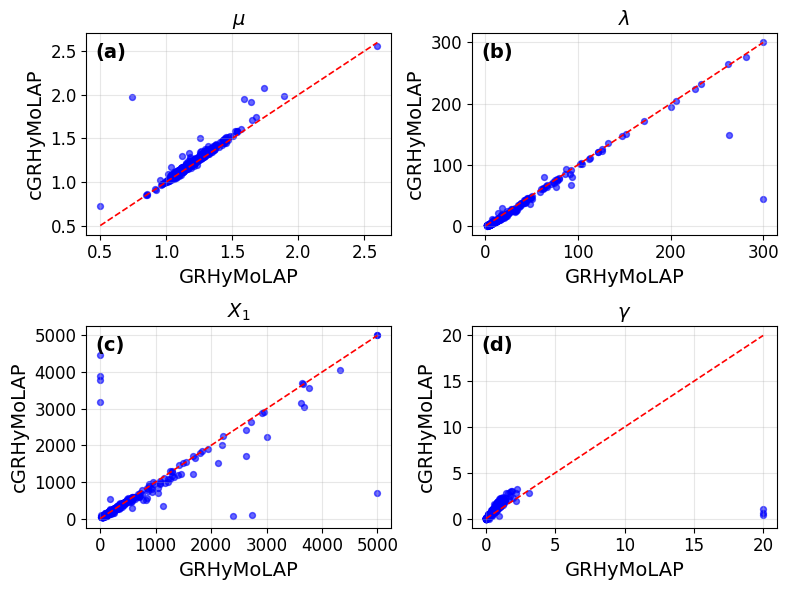

In [ ]:
res1 = results_GRH_semi_exp
res2 = results_cGRH_semi_exp

param_names = [
    r"$\mu$",
    r"$\lambda$",
    r"$X_1$",
    r"$\gamma$"
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

plt.figure(figsize=(8, 6))

for i in range(4):

    p1 = []
    p2 = []

    for s in res1:

        if ("params" in res1[s] and "params" in res2[s]
            and res1[s]["params"] is not None
            and res2[s]["params"] is not None):

            p1.append(res1[s]["params"][i])
            p2.append(res2[s]["params"][i])

    p1 = np.array(p1)
    p2 = np.array(p2)

    ax = plt.subplot(2, 2, i + 1)

    ax.scatter(
        p1,
        p2,
        s=18,
        alpha=0.6,
        color="blue"
    )

    # ligne y = x
    min_v = min(np.min(p1), np.min(p2))
    max_v = max(np.max(p1), np.max(p2))

    ax.plot(
        [min_v, max_v],
        [min_v, max_v],
        "r--",
        linewidth=1.2
    )

    ax.text(
        0.03,
        0.95,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    ax.set_title(
        param_names[i],
        fontsize=14
    )

    ax.set_xlabel(
        "GRHyMoLAP",
        fontsize=14
    )

    ax.set_ylabel(
        "cGRHyMoLAP",
        fontsize=14
    )

    ax.tick_params(
        axis="both",
        labelsize=12
    )

    ax.grid(
        True,
        alpha=0.3
    )

plt.tight_layout()

plt.savefig(
    "parameter_scatter.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

#files.download("parameter_scatter.jpeg")

plt.show()

## Performance class

In [ ]:
import numpy as np

def classify_nse(nse):
    if nse > 0.8:
        return "Very good"
    elif nse > 0.7:
        return "Good"
    elif nse > 0.5:
        return "Satisfactory"
    else:
        return "Unsatisfactory"


models = {
    "GR4J": results_GR4J,
    "GRHyMoLAP": results_GRH_semi_exp,
    "cGRHyMoLAP": results_cGRH_semi_exp,
    "HBV": results_HBV
}

metrics = ["NSE_val"]

for metric in metrics:

    print("\n" + "=" * 70)
    print(f"NSE classification ({metric})")
    print("=" * 70)

    for model_name, dataset in models.items():

        classes = []

        for catch in dataset.keys():

            val = dataset[catch].get(metric, np.nan)

            if np.isnan(val):
                continue

            classes.append(classify_nse(val))

        classes = np.array(classes)

        very_good = np.sum(classes == "Very good")
        good = np.sum(classes == "Good")
        satisfactory = np.sum(classes == "Satisfactory")
        unsatisfactory = np.sum(classes == "Unsatisfactory")

        total = len(classes)

        print(f"\n{model_name}")
        print(f"Very good      : {very_good} ({very_good/total:.2%})")
        print(f"Good           : {good} ({good/total:.2%})")
        print(f"Satisfactory   : {satisfactory} ({satisfactory/total:.2%})")
        print(f"Unsatisfactory : {unsatisfactory} ({unsatisfactory/total:.2%})")


NSE classification (NSE_val)

GR4J
Very good      : 230 (36.92%)
Good           : 189 (30.34%)
Satisfactory   : 125 (20.06%)
Unsatisfactory : 79 (12.68%)

GRHyMoLAP
Very good      : 207 (33.23%)
Good           : 242 (38.84%)
Satisfactory   : 144 (23.11%)
Unsatisfactory : 30 (4.82%)

cGRHyMoLAP
Very good      : 276 (44.30%)
Good           : 228 (36.60%)
Satisfactory   : 94 (15.09%)
Unsatisfactory : 25 (4.01%)

HBV
Very good      : 171 (27.45%)
Good           : 235 (37.72%)
Satisfactory   : 157 (25.20%)
Unsatisfactory : 60 (9.63%)


#Wilcoxon and t-test, cliff's Delta

In [ ]:
from scipy.stats import wilcoxon, ttest_rel
import numpy as np

# =====================================================
# Cliff's Delta function
# =====================================================

def cliffs_delta(x, y):
    n = len(x)
    m = len(y)

    if n == 0 or m == 0:
        return np.nan

    gt = 0
    lt = 0

    for xi in x:
        for yj in y:
            if xi > yj:
                gt += 1
            elif xi < yj:
                lt += 1

    return (gt - lt) / (n * m)

# =====================================================

metrics = [
    "NSE_val",
    "FHV_val",
    "FLV_val",
    "KGE_val"
]

for metric in metrics:

    grhymolap = []
    cgrhymolap = []

    common_catchments = (
        set(results_GRH_semi_exp.keys())
        & set(results_cGRH_semi_exp.keys())
    )

    for catch in common_catchments:

        vg = results_GRH_semi_exp[catch].get(metric, np.nan)
        vc = results_cGRH_semi_exp[catch].get(metric, np.nan)

        if np.isnan(vg) or np.isnan(vc):
            continue

        grhymolap.append(vg)
        cgrhymolap.append(vc)

    grhymolap = np.array(grhymolap)
    cgrhymolap = np.array(cgrhymolap)

    # =====================================================
    # Differences
    # =====================================================

    diff = cgrhymolap - grhymolap

    # =====================================================
    # Tests
    # =====================================================

    stat_w, p_w = wilcoxon(cgrhymolap, grhymolap)
    stat_t, p_t = ttest_rel(cgrhymolap, grhymolap)

    # =====================================================
    # EFFECT SIZE
    # =====================================================

    effect_size = cliffs_delta(cgrhymolap, grhymolap)

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print("\n" + "=" * 60)
    print(metric)
    print("=" * 60)

    print("\ncGRHyMoLAP vs GRHyMoLAP (Wilcoxon)")
    print(f"Wilcoxon W = {stat_w:.4f}")   # 👈 AJOUT IMPORTANT
    print(f"Median Δ   = {np.median(diff):.4f}")
    print(f"p-value    = {p_w:.3e}")

    print(f"\nEffect size (Cliff's delta) = {effect_size:.3f}")

    print("\ncGRHyMoLAP vs GRHyMoLAP (paired t-test)")
    print(f"Mean Δ     = {np.mean(diff):.4f}")
    print(f"t-stat     = {stat_t:.4f}")
    print(f"p-value    = {p_t:.3e}")


NSE_val

cGRHyMoLAP vs GRHyMoLAP (Wilcoxon)
Wilcoxon W = 24386.0000
Median Δ   = 0.0200
p-value    = 5.153e-59

Effect size (Cliff's delta) = 0.151

cGRHyMoLAP vs GRHyMoLAP (paired t-test)
Mean Δ     = 0.0254
t-stat     = 18.4787
p-value    = 4.215e-61

FHV_val

cGRHyMoLAP vs GRHyMoLAP (Wilcoxon)
Wilcoxon W = 23228.0000
Median Δ   = 0.0196
p-value    = 7.554e-61

Effect size (Cliff's delta) = 0.128

cGRHyMoLAP vs GRHyMoLAP (paired t-test)
Mean Δ     = 0.0247
t-stat     = 19.4742
p-value    = 2.602e-66

FLV_val

cGRHyMoLAP vs GRHyMoLAP (Wilcoxon)
Wilcoxon W = 17620.0000
Median Δ   = -0.0527
p-value    = 3.897e-70

Effect size (Cliff's delta) = -0.119

cGRHyMoLAP vs GRHyMoLAP (paired t-test)
Mean Δ     = 29329.9948
t-stat     = 1.0623
p-value    = 2.885e-01

KGE_val

cGRHyMoLAP vs GRHyMoLAP (Wilcoxon)
Wilcoxon W = 29780.0000
Median Δ   = 0.0113
p-value    = 7.511e-51

Effect size (Cliff's delta) = 0.096

cGRHyMoLAP vs GRHyMoLAP (paired t-test)
Mean Δ     = 0.0148
t-stat     = 14.9338
p-

Residus plot

In [ ]:
import matplotlib.lines as mlines

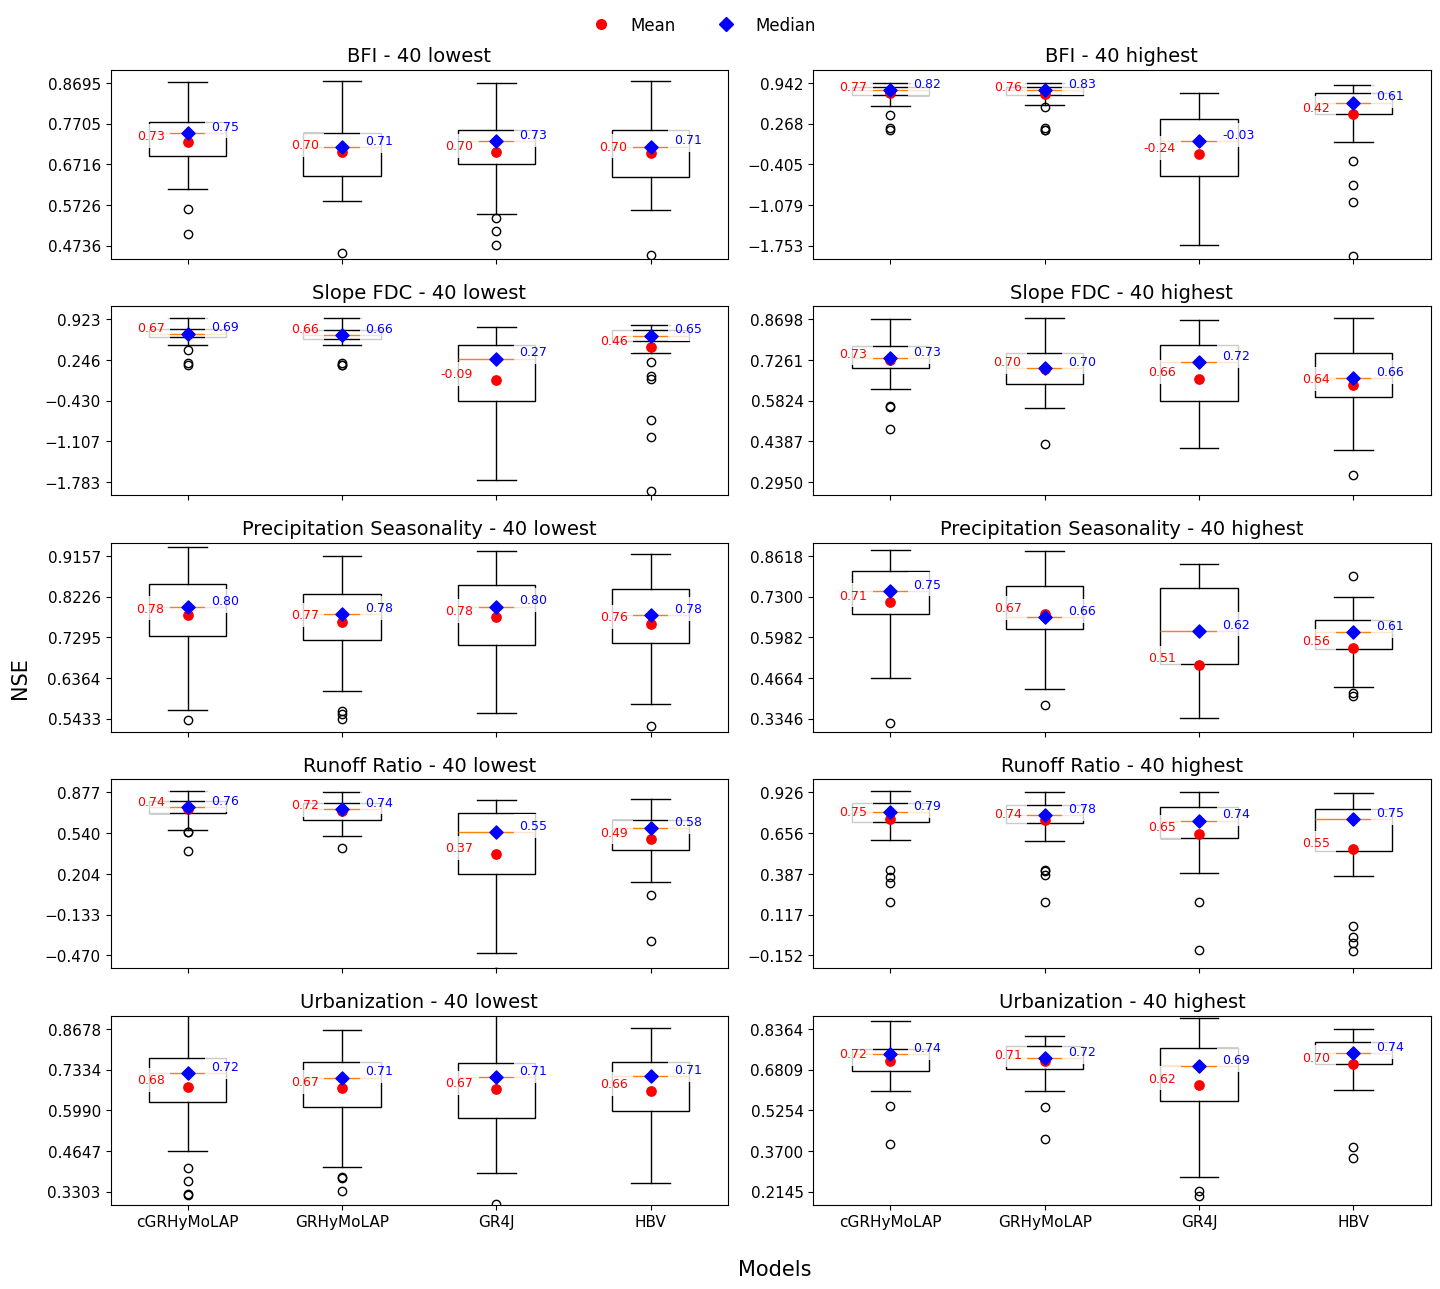

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# STYLE
# ==========================================================
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

# ==========================================================
# VARIABLES
# ==========================================================
variables = [
    "baseflow_index",
    "slope_fdc",
    "p_seasonality",
    "runoff_ratio",
    "urban_perc"
]

var_titles = [
    "BFI",
    "Slope FDC",
    "Precipitation Seasonality",
    "Runoff Ratio",
    "Urbanization"
]

# ==========================================================
# MODELS
# ==========================================================
models = {
    "cGRHyMoLAP": results_cGRH_semi_exp,
    "GRHyMoLAP": results_GRH_semi_exp,
    "GR4J": results_GR4J,
    "HBV": results_HBV,
}

model_names = list(models.keys())

# ==========================================================
# NSE EXTRACTION
# ==========================================================
def extract_nse(results_dict, stations):
    vals = []
    for st in stations['gauge_id']:
        if st in results_dict:
            vals.append(results_dict[st]["NSE_val"])
    return vals

def plot_box(ax, data, title, show_xticks=False):
    ax.boxplot(
    data,
    patch_artist=True,
    showfliers=True,
    widths=0.5,
    boxprops=dict(facecolor='white', color='black')
)

    ax.set_title(title)

    ax.set_xticks(np.arange(1, len(model_names) + 1))
    ax.set_xticklabels([])

    # ======================================================
    # MEAN + MEDIAN
    # ======================================================
    for i, vals in enumerate(data):
        if len(vals) == 0:
            continue

        mean_val = np.mean(vals)
        median_val = np.median(vals)
        x = i + 1

        ax.scatter(x, mean_val, color='red', s=45, zorder=3)
        ax.scatter(x, median_val, color='blue', marker='D', s=45, zorder=3)

        ax.text(x - 0.15, mean_val, f"{mean_val:.2f}",
                color='red', fontsize=9, ha='right', va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        ax.text(x + 0.15, median_val, f"{median_val:.2f}",
                color='blue', fontsize=9, ha='left', va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # ======================================================
    # 🔥 ROBUST LIMITS (IMPORTANT FIX)
    # instead of min/max (too sensitive or too compressed)
    # ======================================================
    all_vals = np.concatenate([np.array(g) for g in data if len(g) > 0])

    ymin = np.percentile(all_vals, 2)
    ymax = np.percentile(all_vals, 98)

    pad = 0.08 * (ymax - ymin + 1e-8)

    ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_yticks(np.linspace(ymin, ymax, 5))

# ==========================================================
# FIGURE
# ==========================================================
fig, axes = plt.subplots(5, 2, figsize=(15, 13))

# ==========================================================
# LOOP VARIABLES
# ==========================================================
for row, (var, title_var) in enumerate(zip(variables, var_titles)):

    if var == "p_seasonality":
        sorted_df = climate[['gauge_id', var]].copy()
    elif var == "urban_perc":
        sorted_df = lc[['gauge_id', var]].copy()
    else:
        sorted_df = hydro[['gauge_id', var]].copy()

    sorted_df['gauge_id'] = sorted_df['gauge_id'].astype(str)

    low_stations = sorted_df.sort_values(var).head(40).reset_index(drop=True)
    high_stations = sorted_df.sort_values(var).tail(40).reset_index(drop=True)

    low_data = []
    high_data = []

    for name, res in models.items():
        low_data.append(extract_nse(res, low_stations))
        high_data.append(extract_nse(res, high_stations))

    plot_box(axes[row, 0], low_data, f"{title_var} - 40 lowest", show_xticks=False)
    plot_box(axes[row, 1], high_data, f"{title_var} - 40 highest", show_xticks=False)

# ==========================================================
# GLOBAL MODEL LABELS (ONLY ONCE)
# ==========================================================
x_positions = np.arange(1, len(model_names) + 1)

fig.text(0.55, 0.04, "Models", ha='center', fontsize=15)



# global y label
fig.text(0.04, 0.5, "NSE", va='center', rotation='vertical', fontsize=15)

for ax in axes[-1, :]:   # seulement dernière ligne
    ax.set_xticks(np.arange(1, len(model_names) + 1))
    ax.set_xticklabels(model_names, rotation=0)

# ==========================================================

mean_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                            markersize=7, label='Mean')

median_marker = mlines.Line2D([], [], color='blue', marker='D', linestyle='None',
                              markersize=7, label='Median')

fig.legend(
    handles=[mean_marker, median_marker],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=12,
    frameon=False
)

plt.tight_layout(rect=[0.05, 0.06, 1, 1])

plt.savefig(
    "specific_catchments.jpeg",
    dpi=700,
    bbox_inches="tight"
)
#files.download("specific_catchments.jpeg")
plt.show()

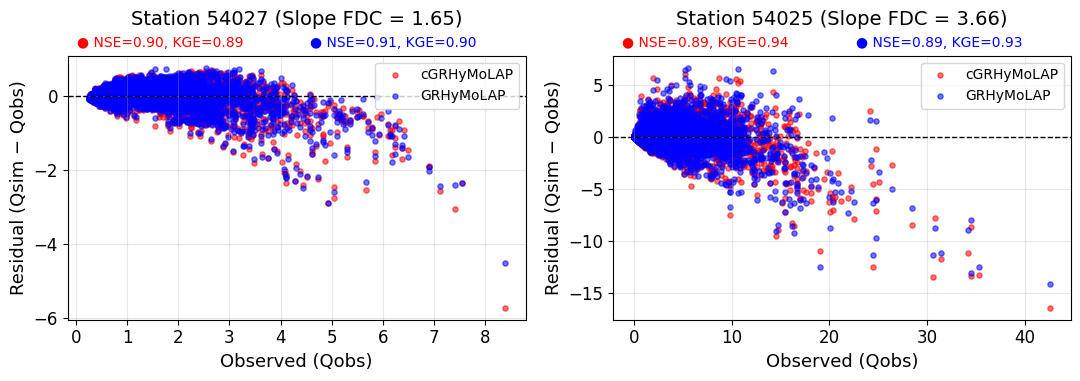

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# SELECT BASINS AT THE 10th AND 90th PERCENTILES
# ==========================================================

fdc = hydro[['gauge_id', 'slope_fdc']].copy()
fdc['gauge_id'] = fdc['gauge_id'].astype(str)

fdc = fdc.sort_values(by='slope_fdc').reset_index(drop=True)

idx10 = int(np.floor(0.10 * (len(fdc) - 1)))
idx90 = int(np.floor(0.90 * (len(fdc) - 1)))

low_fdc_basin = fdc.iloc[idx10]['gauge_id']
high_fdc_basin = fdc.iloc[idx90]['gauge_id']

selected_basins = [low_fdc_basin, high_fdc_basin]

# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, st in zip(axes, selected_basins):

    # ------------------------------------------------------
    # OBSERVED
    # ------------------------------------------------------
    Qobs = np.asarray(results_cGRH_semi_exp[st]["Q_obs"])

    # ------------------------------------------------------
    # cGRHyMoLAP
    # ------------------------------------------------------
    Qsim_c = np.asarray(results_cGRH_semi_exp[st]["Qsim"])
    residuals_c = Qsim_c - Qobs

    nse_c = results_cGRH_semi_exp[st]["NSE_val"]
    kge_c = results_cGRH_semi_exp[st]["KGE_val"]

    # ------------------------------------------------------
    # GRHyMoLAP
    # ------------------------------------------------------
    Qsim_g = np.asarray(results_GRH_semi_exp[st]["Qsim"])
    residuals_g = Qsim_g - Qobs

    nse_g = results_GRH_semi_exp[st]["NSE_val"]
    kge_g = results_GRH_semi_exp[st]["KGE_val"]

    # ------------------------------------------------------
    # SLOPE FDC
    # ------------------------------------------------------
    fdc_val = fdc.loc[
        fdc["gauge_id"] == st,
        "slope_fdc"
    ].values[0]

    # ------------------------------------------------------
    # SCATTER
    # ------------------------------------------------------
    ax.scatter(
        Qobs,
        residuals_c,
        s=14,
        color="red",
        alpha=0.55,
        label="cGRHyMoLAP"
    )

    ax.scatter(
        Qobs,
        residuals_g,
        s=14,
        color="blue",
        alpha=0.55,
        label="GRHyMoLAP"
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    # ------------------------------------------------------
    # TITLE
    # ------------------------------------------------------
    ax.set_title(
        f"Station {st} (Slope FDC = {fdc_val:.2f})",
        fontsize=14,
        pad=22
    )

    # ------------------------------------------------------
    # PERFORMANCE (colored dots only)
    # ------------------------------------------------------
    ax.text(
        0.02,
        1.02,
        f"● NSE={nse_c:.2f}, KGE={kge_c:.2f}",
        transform=ax.transAxes,
        color="red",
        fontsize=10,
        va="bottom"
    )

    ax.text(
        0.53,
        1.02,
        f"● NSE={nse_g:.2f}, KGE={kge_g:.2f}",
        transform=ax.transAxes,
        color="blue",
        fontsize=10,
        va="bottom"
    )

    # ------------------------------------------------------
    # LEGEND
    # ------------------------------------------------------
    ax.legend(
        loc="upper right",
        fontsize=10,
        frameon=True
    )

    # ------------------------------------------------------
    # AXES
    # ------------------------------------------------------
    ax.set_xlabel(
        "Observed (Qobs)",
        fontsize=13
    )

    ax.set_ylabel(
        "Residual (Qsim − Qobs)",
        fontsize=13
    )

    ax.tick_params(
        axis='both',
        labelsize=12
    )

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "error.jpeg",
    dpi=700,
    bbox_inches="tight"
)

#files.download("error.jpeg")

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

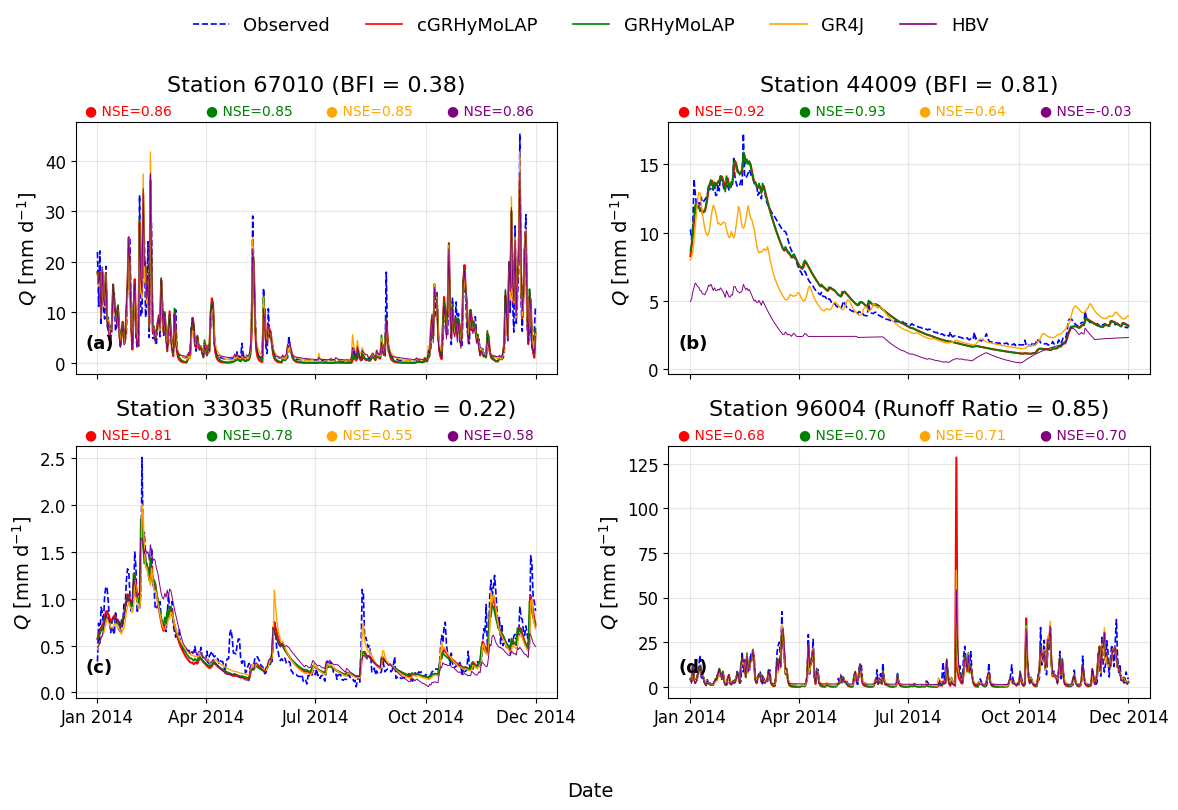

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================================
# SETTINGS
# ==========================================================

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 13
PANEL_SIZE = 13

variables = [
    "baseflow_index",
    "runoff_ratio"
]

# ==========================================================
# DISPLAY NAMES
# ==========================================================

variable_labels = {
    "baseflow_index": "BFI",
    "runoff_ratio": "Runoff Ratio"
}

# ==========================================================
# CORRESPONDING ATTRIBUTE TABLES
# ==========================================================

variable_tables = {
    "baseflow_index": hydro,
    "runoff_ratio": hydro
}

# ==========================================================
# DATES
# ==========================================================

dates = pd.date_range(
    start="2014-01-01",
    periods=365,
    freq="D"
)

# ==========================================================
# COLORS
# ==========================================================

color_obs = "blue"
color_cgrh = "red"
color_grh = "green"
color_gr4j = "orange"
color_hbv = "purple"

# ==========================================================
# FIGURE
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

panel_labels = [
    "(a)", "(b)",
    "(c)", "(d)"
]

# ==========================================================
# LOOP OVER VARIABLES
# ==========================================================

for i, variable in enumerate(variables):

    # ------------------------------------------------------
    # ATTRIBUTE TABLE
    # ------------------------------------------------------

    attr = variable_tables[variable][
        ["gauge_id", variable]
    ].copy()

    attr["gauge_id"] = attr["gauge_id"].astype(str)

    attr = attr.dropna(
        subset=[variable]
    )

    # ------------------------------------------------------
    # SORT
    # ------------------------------------------------------

    attr = attr.sort_values(
        by=variable
    ).reset_index(drop=True)

    # ------------------------------------------------------
    # 5th AND 95th PERCENTILES
    # ------------------------------------------------------

    idx05 = int(
        np.floor(0.055 * (len(attr) - 1))
    )

    idx95 = int(
        np.floor(0.94 * (len(attr) - 1))
    )

    selected_basins = [
        attr.iloc[idx05]["gauge_id"],
        attr.iloc[idx95]["gauge_id"]
    ]

    selected_values = [
        attr.iloc[idx05][variable],
        attr.iloc[idx95][variable]
    ]

    # ======================================================
    # TWO BASINS
    # ======================================================

    for j, st in enumerate(selected_basins):

        ax = axes[i, j]

        value = selected_values[j]

        # --------------------------------------------------
        # OBSERVED
        # --------------------------------------------------

        Q_obs = np.asarray(
            results_cGRH_semi_exp[st]["Q_obs"]
        )

        # --------------------------------------------------
        # cGRHyMoLAP
        # --------------------------------------------------

        Q_cgrh = np.asarray(
            results_cGRH_semi_exp[st]["Qsim"]
        )

        nse_cgrh = results_cGRH_semi_exp[st]["NSE_val"]

        # --------------------------------------------------
        # GRHyMoLAP
        # --------------------------------------------------

        Q_grh = np.asarray(
            results_GRH_semi_exp[st]["Qsim"]
        )

        nse_grh = results_GRH_semi_exp[st]["NSE_val"]

        # --------------------------------------------------
        # GR4J
        # --------------------------------------------------

        Q_gr4j = np.asarray(
            results_GR4J[st]["Qsim"]
        )

        nse_gr4j = results_GR4J[st]["NSE_val"]

        # --------------------------------------------------
        # HBV
        # --------------------------------------------------

        Q_hbv = np.asarray(
            results_HBV[st]["Qsim"]
        )

        nse_hbv = results_HBV[st]["NSE_val"]

        # ==================================================
        # NSE VALUES
        # ==================================================

        ax.text(
            0.02,
            1.02,
            f"● NSE={nse_cgrh:.2f}",
            transform=ax.transAxes,
            color=color_cgrh,
            fontsize=10,
            va="bottom"
        )

        ax.text(
            0.27,
            1.02,
            f"● NSE={nse_grh:.2f}",
            transform=ax.transAxes,
            color=color_grh,
            fontsize=10,
            va="bottom"
        )

        ax.text(
            0.52,
            1.02,
            f"● NSE={nse_gr4j:.2f}",
            transform=ax.transAxes,
            color=color_gr4j,
            fontsize=10,
            va="bottom"
        )

        ax.text(
            0.77,
            1.02,
            f"● NSE={nse_hbv:.2f}",
            transform=ax.transAxes,
            color=color_hbv,
            fontsize=10,
            va="bottom"
        )

        # --------------------------------------------------
        # OBSERVED
        # --------------------------------------------------

        ax.plot(
            dates,
            Q_obs[-365:],
            color=color_obs,
            linestyle="--",
            linewidth=1.2,
            label="Observed"
        )

        # --------------------------------------------------
        # cGRHyMoLAP
        # --------------------------------------------------

        ax.plot(
            dates,
            Q_cgrh[-365:],
            color=color_cgrh,
            linewidth=1.5,
            label="cGRHyMoLAP"
        )

        # --------------------------------------------------
        # GRHyMoLAP
        # --------------------------------------------------

        ax.plot(
            dates,
            Q_grh[-365:],
            color=color_grh,
            linewidth=1.2,
            label="GRHyMoLAP"
        )

        # --------------------------------------------------
        # GR4J
        # --------------------------------------------------

        ax.plot(
            dates,
            Q_gr4j[-365:],
            color=color_gr4j,
            linewidth=1.0,
            label="GR4J"
        )

        # --------------------------------------------------
        # HBV
        # --------------------------------------------------

        ax.plot(
            dates,
            Q_hbv[-365:],
            color=color_hbv,
            linewidth=0.7,
            label="HBV"
        )

        # --------------------------------------------------
        # PANEL LABEL
        # --------------------------------------------------

        ax.text(
            0.02,
            0.16,
            panel_labels[2*i+j],
            transform=ax.transAxes,
            fontsize=PANEL_SIZE,
            fontweight="bold",
            va="top"
        )

        # --------------------------------------------------
        # TITLE
        # --------------------------------------------------

        ax.set_title(
            f"Station {st} "
            f"({variable_labels[variable]} = {value:.2f})",
            fontsize=TITLE_SIZE,
            pad=22
        )

        # --------------------------------------------------
        # Y AXIS
        # --------------------------------------------------

        ax.set_ylabel(
            r"$Q$ [mm d$^{-1}$]",
            fontsize=LABEL_SIZE
        )

        # --------------------------------------------------
        # X AXIS
        # --------------------------------------------------

        ax.set_xticks(
            pd.to_datetime([
                "2014-01-01",
                "2014-04-01",
                "2014-07-01",
                "2014-10-01",
                "2014-12-31"
            ])
        )

        if i < len(variables) - 1:

            ax.set_xticklabels([])

        else:

            ax.set_xticklabels([
                "Jan 2014",
                "Apr 2014",
                "Jul 2014",
                "Oct 2014",
                "Dec 2014"
            ])

        # --------------------------------------------------
        # TICKS
        # --------------------------------------------------

        ax.tick_params(
            axis="both",
            labelsize=TICK_SIZE
        )

        ax.grid(
            alpha=0.3
        )

# ==========================================================
# GLOBAL X LABEL
# ==========================================================

fig.supxlabel(
    "Date",
    fontsize=LABEL_SIZE
)

# ==========================================================
# GLOBAL MODEL LEGEND
# ==========================================================

handles = [
    Line2D(
        [0],
        [0],
        color=color_obs,
        linestyle="--",
        linewidth=1.2,
        label="Observed"
    ),
    Line2D(
        [0],
        [0],
        color=color_cgrh,
        linewidth=1.2,
        label="cGRHyMoLAP"
    ),
    Line2D(
        [0],
        [0],
        color=color_grh,
        linewidth=1.2,
        label="GRHyMoLAP"
    ),
    Line2D(
        [0],
        [0],
        color=color_gr4j,
        linewidth=1.2,
        label="GR4J"
    ),
    Line2D(
        [0],
        [0],
        color=color_hbv,
        linewidth=1.2,
        label="HBV"
    )
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01),
    fontsize=LEGEND_SIZE
)

# ==========================================================
# LAYOUT
# ==========================================================

plt.tight_layout(
    rect=[0, 0.03, 1, 0.94]
)

# ==========================================================
# SAVE
# ==========================================================

plt.savefig(
    "Q_BFI_RunoffRatio_5th_95th.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

files.download("Q_BFI_RunoffRatio_5th_95th.jpeg")

plt.show()